#1. IMPOTAÇÃO DAS BIBLIOTECAS

In [13]:

"""
============================================================

BIBLIOTECAS:

pandas / numpy:
- manipulação dos dados

matplotlib / seaborn:
- visualizações

scikit-learn:
- Machine Learning
- pré-processamento
- métricas
- pipeline
- validação

shap:
- interpretabilidade moderna (XAI)
============================================================
"""

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Pré-processamento
from sklearn.preprocessing import (
    OneHotEncoder,
    MinMaxScaler,
    label_binarize
)

# Tratamento de missing values
from sklearn.impute import SimpleImputer

# Modelo
from sklearn.linear_model import LogisticRegression

# Seleção de features
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

# Grid Search / Validação
from sklearn.model_selection import (
    StratifiedKFold,
    GridSearchCV
)

# Balanceamento
from sklearn.utils.class_weight import (
    compute_sample_weight
)

# Métricas
from sklearn.metrics import (

    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    top_k_accuracy_score
)

# Calibration
from sklearn.calibration import calibration_curve

# PCA / t-SNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Explainable AI
import shap

# Utilitário
from sklearn.utils.validation import check_is_fitted

# Configuração visual
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# 2. CARREGAMENTO DOS DADOS

In [14]:
df_train = pd.read_parquet(
    "datasense_full_train_1sec.parquet"
)

df_test = pd.read_parquet(
    "datasense_full_test_1sec.parquet"
)

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

Train shape: (170393, 115)
Test shape : (56798, 115)


#3. DEFINIÇÃO DO TARGET

In [15]:
"""
============================================================
Definir o problema multiclasse.

TARGET:
label4

label4:
- contém os cenários completos de ataques
- representa 84 classes distintas

EXEMPLOS:
- benign
- dos_syn-flood
- ddos_udp-flood
- reconnaissance_portscan
============================================================
"""

target_col = "label4"

y_train = df_train[target_col]
y_test = df_test[target_col]

print("Quantidade de classes:")
print(y_train.nunique())

print("\nDistribuição das classes:")
display(y_train.value_counts().head(20))

Quantidade de classes:
84

Distribuição das classes:


label4
benign                             102600
mitm_arp-spoofing                    3148
malware_mirai-udp-flood              3006
recon_os-scan                        2969
recon_vuln-scan                      2956
recon_host-disc-tcp-ack-ping         2952
recon_host-disc-tcp-syn-ping         2945
recon_port-scan                      2939
recon_host-disc-tcp-syn-stealth      2933
recon_host-disc-arp-ping             2927
recon_host-disc-udp-ping             2919
malware_mirai-syn-flood              2647
mitm_ip-spoofing                     2280
recon_ping-sweep                     1663
dos_udp-flood                        1292
dos_icmp-flood                       1289
dos_icmp-frag-flood                  1202
ddos_icmp-flood                      1199
ddos_icmp-frag-flood                 1197
ddos_udp-frag-flood                  1197
Name: count, dtype: int64

#4. REMOÇÃO DE COLUNAS

In [16]:
"""
============================================================
Remover apenas labels auxiliares.

Nesta versão:
device_name mantido.

ABORDAGEM:
Context-Aware IDS
============================================================
"""

cols_to_drop = [

    "label1",
    "label2",
    "label3",
    "label4",
    "label_extended"
]

X_train = df_train.drop(columns=cols_to_drop)
X_test = df_test.drop(columns=cols_to_drop)

print("Quantidade de features:")
print(X_train.shape[1])

print("\nFeatures relacionadas aos dispositivos:")

display(

    [col for col in X_train.columns

     if "device" in col.lower()]
)

Quantidade de features:
110

Features relacionadas aos dispositivos:


['device_name', 'device_type']

#5. IDENTIFICAÇÃO DAS FEATURES

In [17]:

# GARANTE CÓPIA
X_train = X_train.copy()
X_test = X_test.copy()


# CONVERTE BOOL PARA STRING
for col in X_train.columns:

    if X_train[col].dtype == "bool":

        X_train[col] = X_train[col].astype(str)

        X_test[col] = X_test[col].astype(str)

# FEATURES NUMÉRICAS
numerical_features = X_train.select_dtypes(

    include=[np.number]

).columns.tolist()

# FEATURES CATEGÓRICAS
categorical_features = [

    col

    for col in X_train.columns

    if col not in numerical_features
]

print("==================================================")
print("IDENTIFICAÇÃO DAS FEATURES FINALIZADA")
print("==================================================")

print("\nQuantidade de features numéricas:")
print(len(numerical_features))

print("\nQuantidade de features categóricas:")
print(len(categorical_features))

print("\nExemplo de categóricas:")
print(categorical_features[:10])

print("\nExemplo de numéricas:")
print(numerical_features[:10])

IDENTIFICAÇÃO DAS FEATURES FINALIZADA

Quantidade de features numéricas:
64

Quantidade de features categóricas:
46

Exemplo de categóricas:
['device_name', 'network_protocols_src_has_udp', 'network_protocols_src_has_ssh', 'network_protocols_src_has_tcp', 'network_protocols_src_has_http', 'network_protocols_src_has_data', 'network_protocols_src_has_xlm', 'network_protocols_src_has_mqtt', 'network_protocols_src_has_lbtrm', 'network_protocols_src_has_dns']

Exemplo de numéricas:
['network_fragmentation-score', 'network_fragmented-packets', 'network_header-length_avg', 'network_header-length_max', 'network_header-length_min', 'network_header-length_std_deviation', 'network_interval-packets', 'network_ip-flags_avg', 'network_ip-flags_max', 'network_ip-flags_min']


#6. PIPELINE DE PRÉ-PROCESSAMENTO

In [18]:
"""
ETAPAS:
- imputação
- normalização
- one-hot encoding

"""

# Pipeline numérica
numeric_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(strategy="median")
    ),

    (
        "scaler",

        MinMaxScaler()
    )
])

# Pipeline categórica
categorical_transformer = Pipeline([

    (
        "imputer",

        SimpleImputer(strategy="most_frequent")
    ),

    (
        "onehot",

        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

# Pipeline completa
preprocessor = ColumnTransformer([

    (
        "num",

        numeric_transformer,

        numerical_features
    ),

    (
        "cat",

        categorical_transformer,

        categorical_features
    )
])

print("Pipeline de pré-processamento criada com sucesso.")

print("\nQuantidade de features numéricas:")
print(len(numerical_features))

print("\nQuantidade de features categóricas:")
print(len(categorical_features))

Pipeline de pré-processamento criada com sucesso.

Quantidade de features numéricas:
64

Quantidade de features categóricas:
46


#7. TRANSFORMAÇÃO DOS DADOS

In [19]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("==================================================")
print("PRÉ-PROCESSAMENTO FINALIZADO")
print("==================================================")

print("\nShape treino:")
print(X_train_processed.shape)

print("\nShape teste:")
print(X_test_processed.shape)

print("\nTipo da matriz:")
print(type(X_train_processed))

PRÉ-PROCESSAMENTO FINALIZADO

Shape treino:
(170393, 190)

Shape teste:
(56798, 190)

Tipo da matriz:
<class 'numpy.ndarray'>


#8. FEATURE SELECTION

In [20]:
"""
Selecionar melhores features.

MÉTODO:
Mutual Information

Obs:
- funciona com variáveis contínuas
- detecta relações não-lineares
- muito usado em IDS

"""

selector = SelectKBest(

    score_func=mutual_info_classif,

    k=180
)

X_train_selected = selector.fit_transform(

    X_train_processed,

    y_train
)

X_test_selected = selector.transform(
    X_test_processed
)
print("==================================================")
print("FEATURE SELECTION FINALIZADA")
print("==================================================")

print("\nQuantidade final de features:")
print(X_train_selected.shape[1])

print("\nShape treino:")
print(X_train_selected.shape)

print("\nShape teste:")
print(X_test_selected.shape)

FEATURE SELECTION FINALIZADA

Quantidade final de features:
180

Shape treino:
(170393, 180)

Shape teste:
(56798, 180)


#9. ANÁLISE DAS FEATURES

In [21]:
"""
============================================================
Analisar:
- features selecionadas
- importância estatística

============================================================
"""

# NOME DAS FEATURES APÓS PREPROCESSAMENTO
feature_names = (

    preprocessor.get_feature_names_out()
)

# MÁSCARA DAS FEATURES SELECIONADAS
selected_mask = selector.get_support()

# FEATURES SELECIONADAS
selected_features = feature_names[
    selected_mask
]

# SCORES DAS FEATURES
scores = selector.scores_[selected_mask]

# DATAFRAME DE IMPORTÂNCIA
feature_importance = pd.DataFrame({

    "Feature": selected_features,

    "Mutual_Information": scores
})

# ORDENA POR IMPORTÂNCIA
feature_importance = feature_importance.sort_values(

    by="Mutual_Information",

    ascending=False
)

# RESET INDEX
feature_importance = feature_importance.reset_index(
    drop=True
)

print("==================================================")
print("ANÁLISE DAS FEATURES FINALIZADA")
print("==================================================")

print("\nQuantidade de features selecionadas:")
print(len(feature_importance))

print("\nTop 20 features mais importantes:")

display(
    feature_importance.head(20)
)

ANÁLISE DAS FEATURES FINALIZADA

Quantidade de features selecionadas:
180

Top 20 features mais importantes:


,Feature,Mutual_Information
0,num__network_ip-length_avg,1.075357
1,num__network_packets_all_count,0.990666
2,num__network_packets_dst_count,0.990207
3,num__network_interval-packets,0.971996
4,num__network_window-size_avg,0.909465
5,num__network_time-delta_avg,0.878334
6,num__network_ports_all_count,0.844133
7,num__network_ttl_avg,0.833046
8,num__network_ports_src_count,0.831729
9,num__network_tcp-flags_avg,0.828431


#10. VISUALIZAÇÃO DAS FEATURES

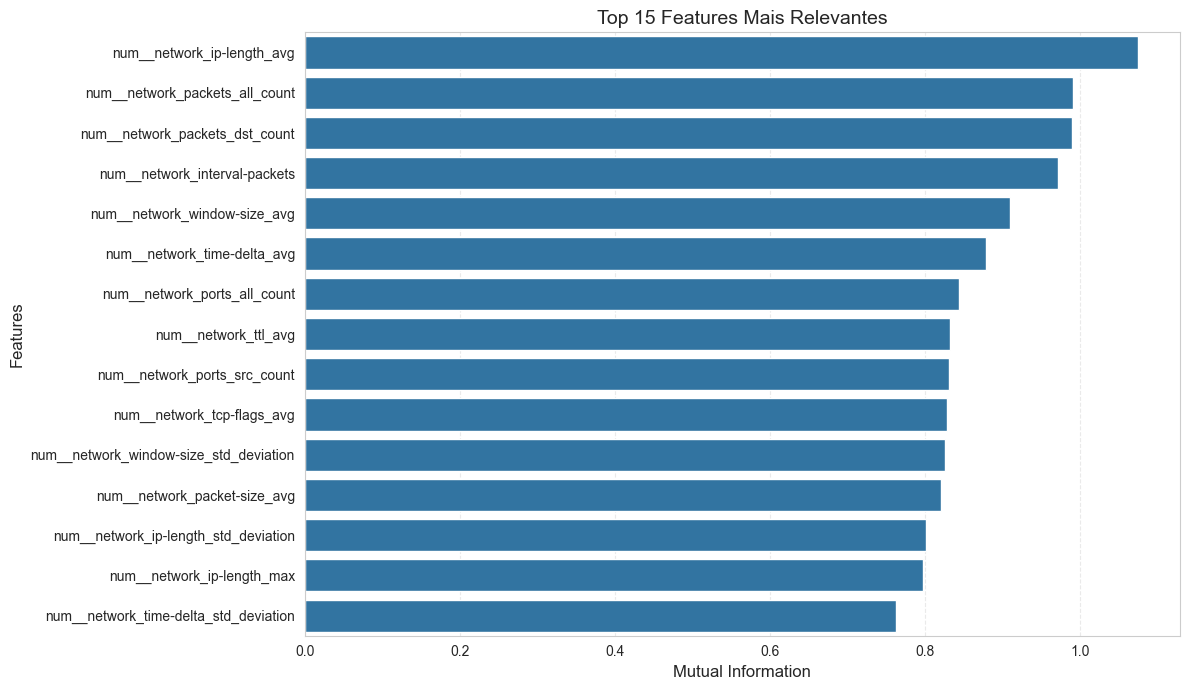

VISUALIZAÇÃO DAS FEATURES FINALIZADA


In [22]:

# TOP FEATURES
top_features = feature_importance.head(15)

# FIGURA
plt.figure(figsize=(12,7))


# BARPLOT
sns.barplot(

    data=top_features,

    x="Mutual_Information",

    y="Feature"
)


# TÍTULO
plt.title(

    "Top 15 Features Mais Relevantes",

    fontsize=14
)


# LABELS
plt.xlabel(

    "Mutual Information",

    fontsize=12
)

plt.ylabel(

    "Features",

    fontsize=12
)


# GRID
plt.grid(

    axis="x",

    linestyle="--",

    alpha=0.4
)

# AJUSTE FINAL
plt.tight_layout()


# EXIBE
plt.show()

print("==================================================")
print("VISUALIZAÇÃO DAS FEATURES FINALIZADA")
print("==================================================")

#11. SAMPLE WEIGHT

In [23]:
"""
============================================================

OBJETIVO:
Balancear automaticamente as classes.

============================================================
"""

sample_weight = compute_sample_weight(

    class_weight="balanced",

    y=y_train
)

print("Sample weights calculados.")

Sample weights calculados.


#12. DEFINIÇÃO DO MODELO

In [24]:

model = LogisticRegression(

    max_iter=3000,

    C=1.0,

    tol=1e-3,

    random_state=42,

    n_jobs=-1
)

print("Modelo criado com sucesso.")

Modelo criado com sucesso.


#13. GRID SEARCH

In [25]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("==================================================")
print("PRÉ-PROCESSAMENTO FINALIZADO")
print("==================================================")

print("\nShape treino:")
print(X_train_processed.shape)

print("\nShape teste:")
print(X_test_processed.shape)

print("\nTipo da matriz:")
print(type(X_train_processed))

PRÉ-PROCESSAMENTO FINALIZADO

Shape treino:
(170393, 190)

Shape teste:
(56798, 190)

Tipo da matriz:
<class 'numpy.ndarray'>


In [26]:
"""
============================================================

OBJETIVO:
Buscar melhores hiperparâmetros.

MÉTRICA:
F1 Macro

============================================================
"""

param_grid = {

    "C": [0.3, 0.7, 1.0]
}

cv = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=42
)

grid = GridSearchCV(

    estimator=model,

    param_grid=param_grid,

    scoring="f1_macro",

    cv=cv,

    n_jobs=-1,

    verbose=2,

    return_train_score=True
)

grid.fit(

    X_train_selected,

    y_train,

    sample_weight=sample_weight
)

print("Melhores parâmetros:")
print(grid.best_params_)

print("\nMelhor F1 Macro:")
print(grid.best_score_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\bruno.lima\Documents\Projeto IIoT Multiclasse\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Melhores parâmetros:
{'C': 1.0}

Melhor F1 Macro:
0.7040238764070645


#14. PREDIÇÃO MULTICLASSE

In [27]:
"""
============================================================

OBJETIVO:
Executar:
- predições
- probabilidades
- análise de confiança

============================================================
"""

best_model = grid.best_estimator_

check_is_fitted(best_model)

# probabilidades
y_prob = best_model.predict_proba(
    X_test_selected
)

# predição final
y_pred = best_model.predict(
    X_test_selected
)

# classes
classes = best_model.classes_

# maior probabilidade
max_prob = np.max(y_prob, axis=1)

# segunda maior probabilidade
sorted_probs = np.sort(y_prob, axis=1)

second_best_prob = sorted_probs[:, -2]

# margem de confiança
confidence_margin = (

    max_prob -

    second_best_prob
)

# dataframe final
df_result = pd.DataFrame({

    "Classe_Real": y_test.values,

    "Classe_Predita": y_pred,

    "Probabilidade_Maxima": max_prob,

    "Segunda_Probabilidade": second_best_prob,

    "Margem_Confianca": confidence_margin
})

# correto/incorreto
df_result["Correto"] = (

    df_result["Classe_Real"]

    ==

    df_result["Classe_Predita"]
)

print("Quantidade total:")
print(len(df_result))

print("\nPredições corretas:")
print(df_result["Correto"].sum())

print("\nPredições incorretas:")
print((~df_result["Correto"]).sum())

display(df_result.head())

Quantidade total:
56798

Predições corretas:
17401

Predições incorretas:
39397


,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
0,benign,dos_http-flood-port-443,0.523729,0.203669,0.320060,False
1,benign,ddos_synonymousip-flood-port-80,0.324515,0.082128,0.242387,False
2,benign,benign,0.196576,0.180048,0.016527,True
3,recon_host-disc-tcp-ack-ping,recon_os-scan,0.149465,0.141283,0.008182,False
4,benign,recon_ping-sweep,0.162399,0.096987,0.065412,False


#15. AMOSTRAS MAIS CONFIANTES

In [28]:
"""
============================================================

OBJETIVO:
Mostrar amostras com maior confiança.

============================================================
"""

mais_confiantes = df_result.sort_values(

    by="Probabilidade_Maxima",

    ascending=False
)

display(
    mais_confiantes.head(20)
)

print("Quantidade de classes:")
print(y_prob.shape)

,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
36141,web_command-injection,web_command-injection,1.000000,1.037754e-07,1.000000,True
25368,web_backdoor-upload,web_backdoor-upload,1.000000,9.460841e-08,1.000000,True
1847,recon_os-scan,recon_os-scan,0.999999,1.925289e-07,0.999999,True
29550,web_backdoor-upload,web_backdoor-upload,0.999999,2.432485e-07,0.999999,True
44672,recon_os-scan,recon_os-scan,0.999999,2.337925e-07,0.999999,True
27714,dos_http-flood-port-443,dos_http-flood-port-443,0.999999,1.880056e-07,0.999999,True
40386,recon_os-scan,recon_os-scan,0.999999,2.400581e-07,0.999999,True
41822,recon_os-scan,recon_os-scan,0.999999,2.672639e-07,0.999999,True
8766,recon_os-scan,recon_os-scan,0.999999,2.873834e-07,0.999999,True
29033,recon_os-scan,recon_os-scan,0.999999,3.281419e-07,0.999999,True


Quantidade de classes:
(56798, 84)


#16. AMOSTRAS MAIS INCERTAS

In [29]:
"""
============================================================

OBJETIVO:
Mostrar amostras mais difíceis.

============================================================
"""

mais_incertas = df_result.sort_values(

    by="Margem_Confianca",

    ascending=True
)

display(
    mais_incertas.head(20)
)

,Classe_Real,Classe_Predita,Probabilidade_Maxima,Segunda_Probabilidade,Margem_Confianca,Correto
32186,recon_host-disc-tcp-ack-ping,recon_vuln-scan,0.142956,0.142956,3.493391e-07,False
54174,recon_host-disc-tcp-ack-ping,recon_host-disc-tcp-syn-stealth,0.153078,0.153078,4.076958e-07,False
4570,recon_os-scan,recon_os-scan,0.150894,0.150894,4.123314e-07,True
14756,recon_host-disc-arp-ping,recon_host-disc-tcp-syn-stealth,0.159916,0.159910,5.729591e-06,False
52792,benign,dos_syn-flood-port-554,0.100780,0.100772,7.972988e-06,False
18039,recon_host-disc-tcp-ack-ping,recon_host-disc-udp-ping,0.153023,0.153014,8.994820e-06,False
22957,recon_vuln-scan,recon_os-scan,0.137867,0.137857,9.989823e-06,False
5415,malware_mirai-syn-flood,dos_slowloris-port-1883,0.236617,0.236607,1.008119e-05,False
52543,recon_host-disc-tcp-syn-stealth,recon_os-scan,0.137653,0.137643,1.040998e-05,False
21723,recon_host-disc-tcp-syn-stealth,recon_host-disc-udp-ping,0.142129,0.142118,1.062041e-05,False


#17. MÉTRICAS

In [30]:
"""

Avaliar desempenho do modelo.

"""

print("Accuracy:")
print(
    accuracy_score(y_test, y_pred)
)

print("\nF1 Macro:")
print(
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

print("\nF1 Weighted:")
print(
    f1_score(
        y_test,
        y_pred,
        average="weighted"
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0

    )
)

Accuracy:
0.3063664213528645

F1 Macro:
0.5529263012875048

F1 Weighted:
0.35824804611201017

Classification Report:
                                   precision    recall  f1-score   support

                           benign       0.90      0.17      0.28     34200
        bruteforce_dictionary-ssh       0.52      0.44      0.48       240
     bruteforce_dictionary-telnet       0.13      0.75      0.22       225
    ddos_ack-frag-flood-port-1883       0.72      0.84      0.77       232
      ddos_ack-frag-flood-port-80       0.63      0.75      0.68       168
               ddos_connect-flood       0.38      0.87      0.53        15
        ddos_http-flood-port-1883       0.67      0.78      0.72       225
          ddos_http-flood-port-80       0.59      0.72      0.65       167
                  ddos_icmp-flood       0.93      0.75      0.83       400
             ddos_icmp-frag-flood       0.87      0.75      0.81       395
          ddos_mqtt-publish-flood       0.86      0.80   

#18. TOP-K ACCURACY

In [31]:
"""
============================================================

OBJETIVO:
Avaliar:
- Top-1
- Top-3
- Top-5

============================================================
"""

top1 = top_k_accuracy_score(

    y_test,

    y_prob,

    k=1,

    labels=classes
)

top3 = top_k_accuracy_score(

    y_test,

    y_prob,

    k=3,

    labels=classes
)

top5 = top_k_accuracy_score(

    y_test,

    y_prob,

    k=5,

    labels=classes
)

print("Top-1 Accuracy:", top1)
print("Top-3 Accuracy:", top3)
print("Top-5 Accuracy:", top5)

Top-1 Accuracy: 0.3063664213528645
Top-3 Accuracy: 0.6534737138631642
Top-5 Accuracy: 0.8228458748547484


#19. ROC-AUC MULTICLASSE

In [32]:
"""
============================================================

OBJETIVO:
ROC-AUC One-vs-Rest multiclasses.

============================================================
"""

y_test_bin = label_binarize(

    y_test,

    classes=classes
)

roc_auc_macro = roc_auc_score(

    y_test_bin,

    y_prob,

    average="macro",

    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(

    y_test_bin,

    y_prob,

    average="weighted",

    multi_class="ovr"
)

print("ROC-AUC Macro:")
print(roc_auc_macro)

print("\nROC-AUC Weighted:")
print(roc_auc_weighted)

ROC-AUC Macro:
0.9672983887673785

ROC-AUC Weighted:
0.9127167663938599


#20. MATRIZ DE CONFUSÃO

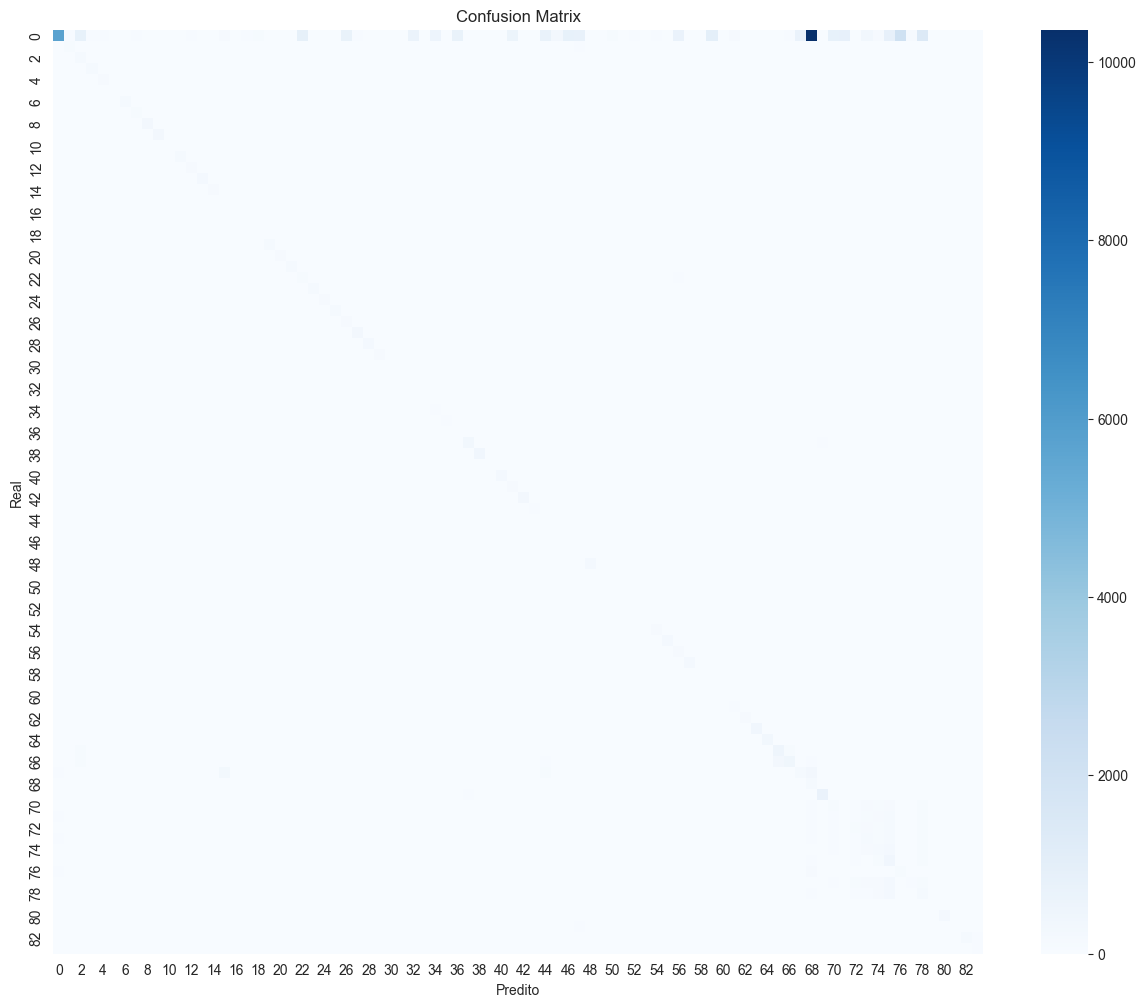

In [33]:
"""
============================================================

OBJETIVO:
Visualizar erros do modelo.

============================================================
"""

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

#21. CLASSES MAIS CONFUNDIDAS

In [34]:
"""
============================================================

OBJETIVO:
Encontrar ataques mais confundidos.

============================================================
"""

confusions = []

for i in range(len(classes)):

    for j in range(len(classes)):

        if i != j:

            confusions.append({

                "Classe_Real": classes[i],

                "Classe_Predita": classes[j],

                "Quantidade": cm[i, j]
            })

conf_df = pd.DataFrame(confusions)

conf_df = conf_df.sort_values(

    by="Quantidade",

    ascending=False
)

display(conf_df.head(20))

,Classe_Real,Classe_Predita,Quantidade
67,benign,mitm_impersonation,10359
75,benign,recon_ping-sweep,2122
77,benign,recon_vuln-scan,1450
58,benign,dos_tcp-flood-port-23,1008
21,benign,ddos_synonymousip-flood-port-80,901
74,benign,recon_os-scan,878
70,benign,recon_host-disc-tcp-ack-ping,862
45,benign,dos_slowloris-port-80,829
69,benign,recon_host-disc-arp-ping,828
1,benign,bruteforce_dictionary-telnet,820


#22. PCA

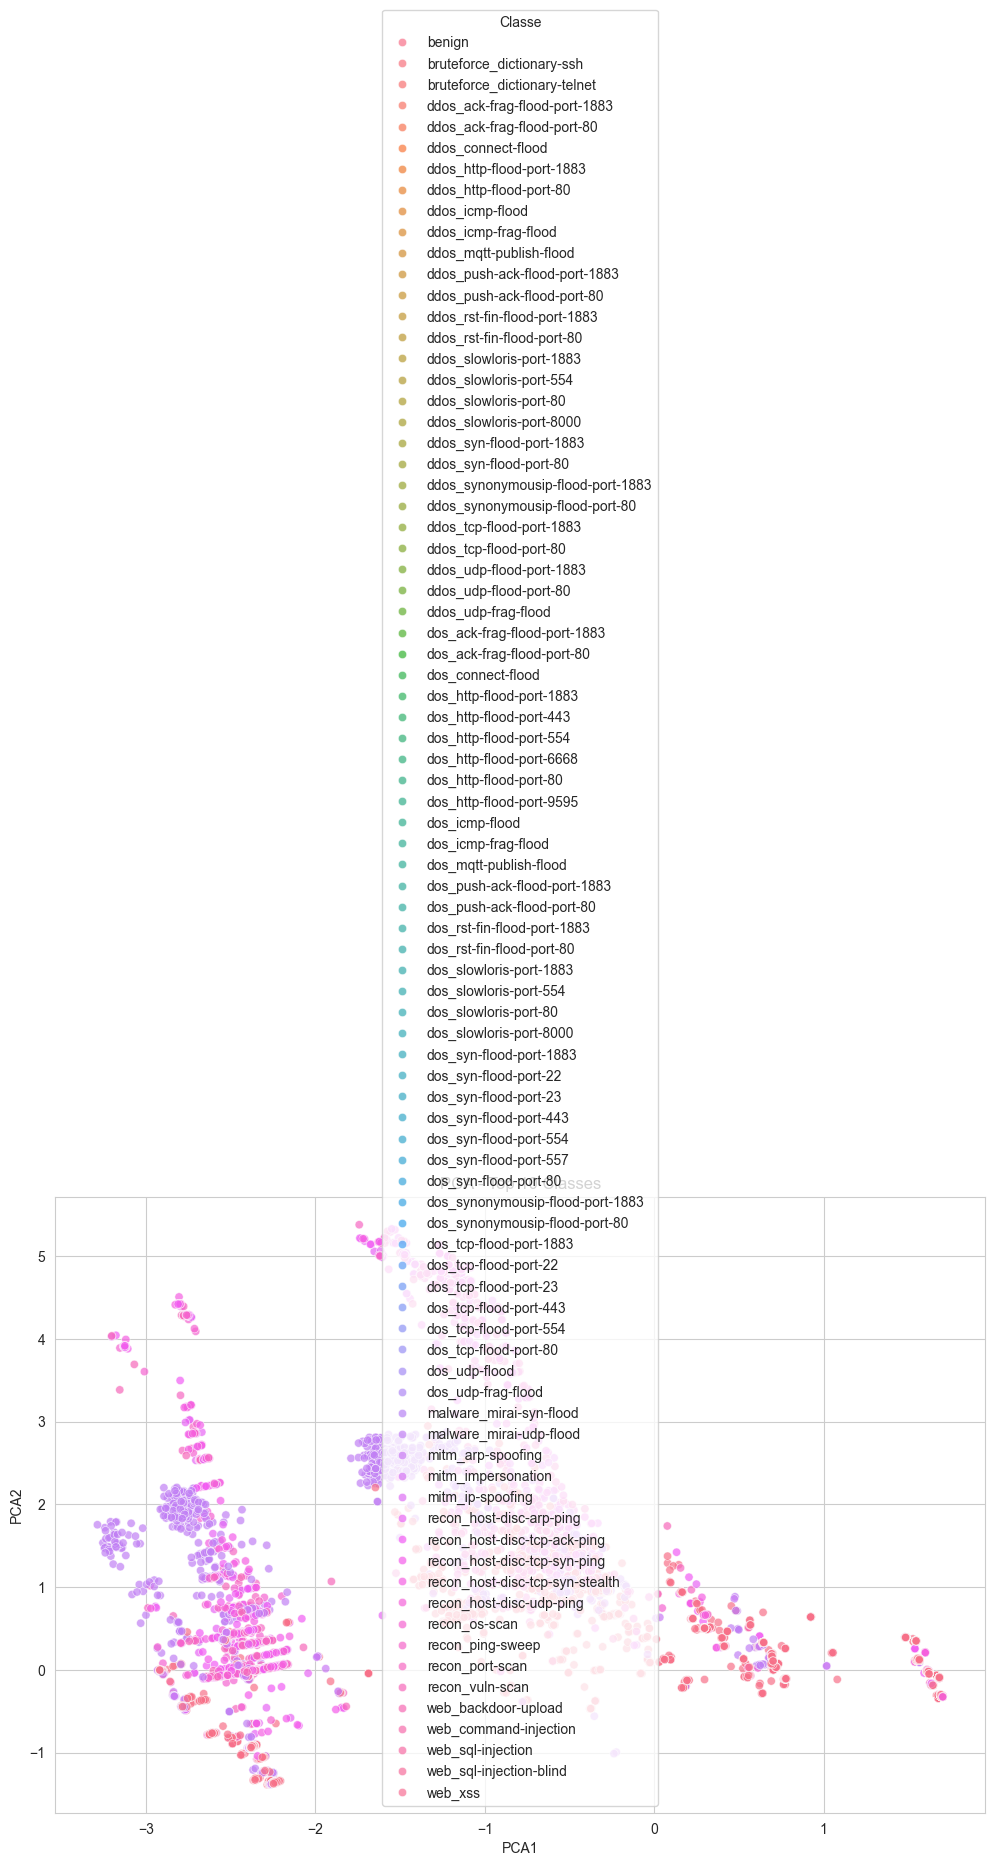

In [35]:

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_test_selected
)

df_pca = pd.DataFrame({

    "PCA1": X_pca[:,0],

    "PCA2": X_pca[:,1],

    "Classe": y_test.values
})

top_classes = (
    y_test.value_counts()
    .head(10)
    .index
)

df_plot = df_pca[
    df_pca["Classe"].isin(top_classes)
]

plt.figure(figsize=(12,8))

sns.scatterplot(

    data=df_plot,

    x="PCA1",

    y="PCA2",

    hue="Classe",

    alpha=0.7
)

plt.title("PCA - Top 10 Classes")

plt.show()

#24. t-SNE

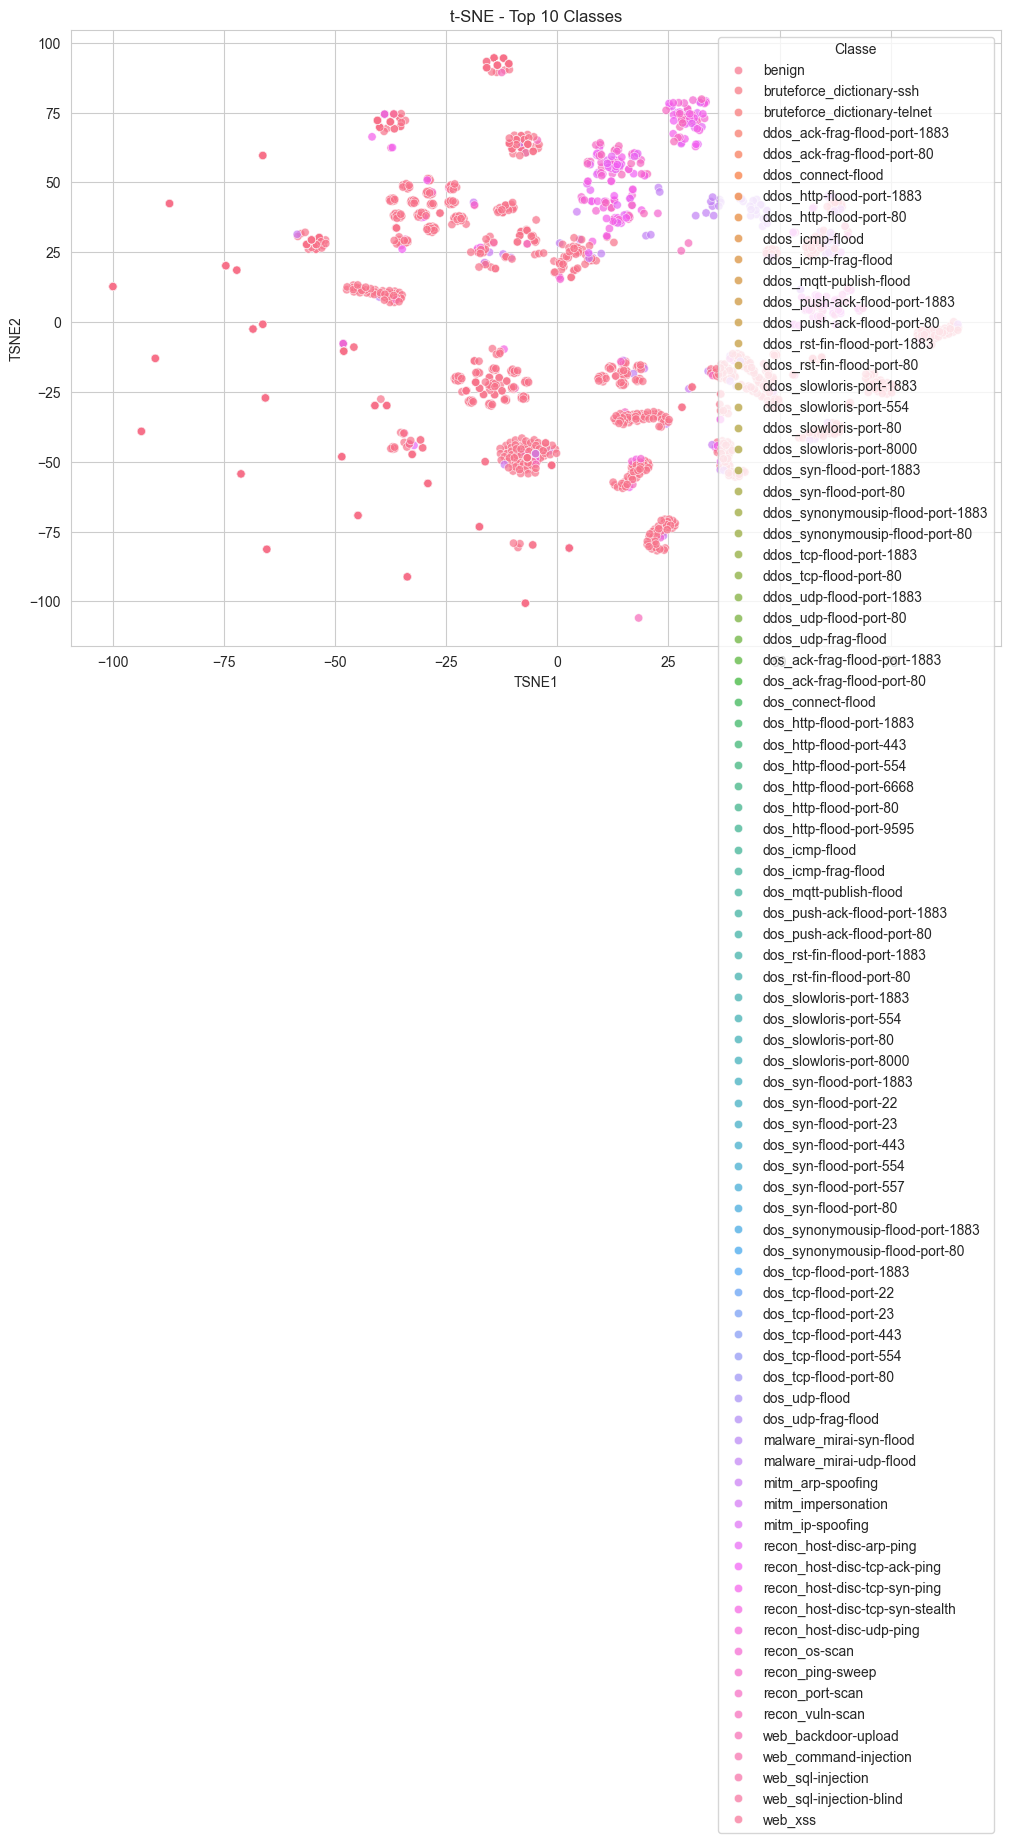

In [36]:

sample_size = 3000

X_tsne_sample = X_test_selected[:sample_size]

y_tsne_sample = y_test.iloc[:sample_size]

tsne = TSNE(

    n_components=2,

    perplexity=30,

    random_state=42
)

X_tsne = tsne.fit_transform(
    X_tsne_sample
)

df_tsne = pd.DataFrame({

    "TSNE1": X_tsne[:,0],

    "TSNE2": X_tsne[:,1],

    "Classe": y_tsne_sample.values
})

top_classes = (
    y_test.value_counts()
    .head(10)
    .index
)

df_plot = df_tsne[
    df_tsne["Classe"].isin(top_classes)
]

plt.figure(figsize=(12,8))

sns.scatterplot(

    data=df_plot,

    x="TSNE1",

    y="TSNE2",

    hue="Classe",

    alpha=0.7
)

plt.title("t-SNE - Top 10 Classes")

plt.show()

#25. SHAP VALUES

In [37]:
"""
============================================================

SHAP EXPLAINABILITY - NÍVEL MESTRADO (IDS MULTICLASSE)

OBJETIVOS:
✔ Importância global robusta
✔ Explicação por classe (ataques vs benign)
✔ Análise de instâncias críticas
✔ Estabilidade (consistência do modelo)
✔ Visualização interpretável para artigo científico

============================================================
"""

# 1. AMOSTRAGEM CONTROLADA
sample_size = 1500
X_sample = X_test_selected[:sample_size]


# 2. EXPLAINER LINEAR (LOGISTIC REGRESSION)
explainer = shap.LinearExplainer(
    best_model,
    X_sample,
    feature_perturbation="interventional"
)

shap_values = explainer.shap_values(X_sample)

class_names = best_model.classes_


# 3. SHAP GLOBAL (IMPORTÂNCIA MÉDIA)
global_importance = np.mean(
    [np.abs(sv) for sv in shap_values],
    axis=0
)

df_global = pd.DataFrame({
    "Feature": selected_features,
    "SHAP_Global": global_importance
}).sort_values(
    by="SHAP_Global",
    ascending=False
)

print("\n==============================")
print("TOP FEATURES - IMPORTÂNCIA GLOBAL")
print("==============================")
display(df_global.head(20))


# 4. VISUAL GLOBAL
plt.figure(figsize=(10,6))

top_features = df_global.head(15)

plt.barh(
    top_features["Feature"][::-1],
    top_features["SHAP_Global"][::-1]
)

plt.title("SHAP Global Importance - IDS Multiclasse")
plt.xlabel("Mean |SHAP value|")

plt.show()

# 5. SHAP POR CLASSE (ATAQUE vs BENIGN)
class_analysis = {}

print("\n==============================")
print("SHAP POR CLASSE (TOP FEATURES)")
print("==============================")

for i, cls in enumerate(class_names):

    mean_class = np.mean(
        np.abs(shap_values[i]),
        axis=0
    )

    df_class = pd.DataFrame({
        "Feature": selected_features,
        "Impact": mean_class
    }).sort_values(
        by="Impact",
        ascending=False
    )

    class_analysis[cls] = df_class

    print(f"\n>>> Classe: {cls}")
    display(df_class.head(8))

# 6. COMPARAÇÃO ENTRE CLASSES (INSIGHT DE ATAQUE)
target_classes = [
    class_names[0],
    class_names[min(1, len(class_names)-1)],
    class_names[min(2, len(class_names)-1)]
]

comparison = {}

for cls in target_classes:

    idx = list(class_names).index(cls)

    comparison[cls] = np.mean(
        np.abs(shap_values[idx]),
        axis=0
    )

df_compare = pd.DataFrame(
    comparison,
    index=selected_features
)

print("\n==============================")
print("COMPARAÇÃO ENTRE CLASSES")
print("==============================")
display(df_compare.head(15))

# 7. SHAP LOCAL (CASO CRÍTICO)
print("\n==============================")
print("SHAP LOCAL - CASO CRÍTICO")
print("==============================")

# pegar primeiro erro do modelo
error_idx = df_result[
    df_result["Classe_Real"] != df_result["Classe_Predita"]
].index[0]

class_idx = list(class_names).index(
    df_result.loc[error_idx, "Classe_Predita"]
)

shap.force_plot(
    explainer.expected_value[class_idx],
    shap_values[class_idx][error_idx],
    X_sample[error_idx],
    feature_names=selected_features,
    matplotlib=True
)

# 8. CONSISTÊNCIA (ROBUSTEZ DO MODELO)
print("\n==============================")
print("SHAP CONSISTENCY SCORE")
print("==============================")

n_runs = 5
importance_runs = []

for _ in range(n_runs):

    idx = np.random.choice(
        len(X_test_selected),
        1000,
        replace=False
    )

    X_temp = X_test_selected[idx]

    sv_temp = explainer.shap_values(X_temp)

    mean_temp = np.mean(
        [np.abs(sv) for sv in sv_temp],
        axis=0
    )

    importance_runs.append(mean_temp)

consistency = np.std(importance_runs, axis=0)

df_consistency = pd.DataFrame({
    "Feature": selected_features,
    "Stability": consistency
}).sort_values(
    by="Stability"
)

print("\nFEATURES MAIS ESTÁVEIS (MAIS CONFIÁVEIS)")
display(df_consistency.head(15))

c:\Users\bruno.lima\Documents\Projeto IIoT Multiclasse\venv\Lib\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


ValueError: Per-column arrays must each be 1-dimensional